<a href="https://colab.research.google.com/github/peterbmob/CH-PFC/blob/main/CHPFC_funkar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Minimal CH-PFC (Cahn–Hilliard + Phase-Field Crystal) implementation
sufficient to qualitatively reproduce the results in Balakrishna et al. (2019),
Phys. Rev. Materials 3, 065404.

This code is written for clarity and instructional purposes—optimized methods
(e.g., spectral solvers) can significantly accelerate it in research workflows.
"""
from __future__ import annotations
import numpy as np
import os, sys, numpy as np, matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter, maximum_filter
from scipy.spatial import Voronoi
from dataclasses import dataclass

# -----------------------
# Utilities and operators
# -----------------------

def plot_fields(c, psi, mask, title_prefix=''):
    fig, axs = plt.subplots(1, 3, figsize=(10, 3.2))
    im0 = axs[0].imshow(c.T, origin='lower', cmap='viridis', vmin=0, vmax=1)
    axs[0].set_title(f'{title_prefix} c')
    plt.colorbar(im0, ax=axs[0], fraction=0.046)

    # Add a ring for the particle boundary to the c-plot
    ny, nx = mask.shape
    # Assuming the mask is a circle, find the center and radius
    # This is a simplified approach and might need adjustment for non-circular masks
    y_coords, x_coords = np.nonzero(mask)
    if len(x_coords) > 0 and len(y_coords) > 0:
        center_x = np.mean(x_coords)
        center_y = np.mean(y_coords)
        # Estimate radius from area
        area = np.sum(mask)
        radius = np.sqrt(area / np.pi)

        # Create a circle patch
        circle = plt.Circle((center_x, center_y), radius, color='red', fill=False, linewidth=1.5)
        axs[0].add_patch(circle)


    im1 = axs[1].imshow(psi.T, origin='lower', cmap='coolwarm')
    axs[1].set_title('psi')
    plt.colorbar(im1, ax=axs[1], fraction=0.046)
    im2 = axs[2].imshow(mask.T, origin='lower', cmap='gray')
    axs[2].set_title('mask')
    plt.tight_layout()
    return fig, axs


def periodic_pad(u):
    return u


def laplacian(u, dx):
    """Standard 5-point periodic Laplacian."""
    return (
        -4*u
        + np.roll(u,1,axis=0) + np.roll(u,-1,axis=0)
        + np.roll(u,1,axis=1) + np.roll(u,-1,axis=1)
    )/(dx*dx)

def d2x(u, dx):
    return (np.roll(u, -1, axis=0) - 2.0*u + np.roll(u, 1, axis=0)) / (dx*dx)

def d2y(u, dx):
    return (np.roll(u, -1, axis=1) - 2.0*u + np.roll(u, 1, axis=1)) / (dx*dx)

def d2xy(u, dx):
    return ( np.roll(np.roll(u, -1, axis=0), -1, axis=1)
           - np.roll(np.roll(u, -1, axis=0),  1, axis=1)
           - np.roll(np.roll(u,  1, axis=0), -1, axis=1)
           + np.roll(np.roll(u,  1, axis=0),  1, axis=1) ) / (4.0*dx*dx)

def anisotropic_laplacian_c(u, c, alpha_fp, beta_fp, alpha_lfp, beta_lfp, dx, xi=1.0):
    # interpolate α(c), β(c)  (Eq. A4)
    alpha = alpha_fp + (alpha_lfp - alpha_fp)*c
    beta  = beta_fp  + (beta_lfp  - beta_fp )*c
    A11, A12, A22 = alpha, -alpha/np.sqrt(3.0), 2.0*beta/np.sqrt(3.0)

    # coefficients in Eq. (A3)
    coeff_xx = (A11*A11 + A12*A12) * (xi*xi)
    coeff_yy = (A22*A22)           * (xi*xi)
    coeff_xy = (2.0*A12*A22)       * (xi*xi)

    u_xx = d2x(u, dx)
    u_yy = d2y(u, dx)
    u_xy = d2xy(u, dx)

    return coeff_xx*u_xx + coeff_yy*u_yy + coeff_xy*u_xy

def apply_G2(u, c, p):
    # (1 + ∇_c^2)^2 u = u + 2 ∇_c^2 u + (∇_c^2)(∇_c^2 u)
    Lu   = anisotropic_laplacian_c(u, c, p.alpha_fp, p.beta_fp, p.alpha_lfp, p.beta_lfp, p.dx, p.xi)
    L2u  = anisotropic_laplacian_c(Lu, c, p.alpha_fp, p.beta_fp, p.alpha_lfp, p.beta_lfp, p.dx, p.xi)
    return u + 2.0*Lu + L2u

# Define the ch_step_spectral function directly in the notebook (re-defining to be sure)
# This version includes the mobility_base and mobility_grain_boundary arguments
# and calls the calculate_mobility function defined above.
def ch_step_spectral(
    c, psi, p, cache, *, dt=1e-3, n_sub=1, mask=None,
    kappa_iso=None, mu_coupling=None, reservoir_value=1.0,
    mobility_base=1.0, mobility_grain_boundary=1.0 # Added mobility parameters
):
    c = np.asarray(c, dtype=np.float64, order='C').copy()
    if kappa_iso is None:
        kappa_iso = float(p.kappa)
    for _ in range(n_sub):
        mu = mu_chem_regular_solution(c, float(p.RT), float(p.Om)) # mu_chem_regular_solution is from a previous cell
        mu -= laplace_fft(c, cache) # laplace_fft is from a previous cell
        if callable(mu_coupling):
            mu += mu_coupling(c, psi)

        # Calculate the spatially varying mobility M
        M = calculate_mobility(c, psi, mask, mobility_base=mobility_base, mobility_grain_boundary=mobility_grain_boundary)

        # Use the spatially varying mobility M in the divergence term
        div_term = div_of_M_grad_mu_fft(M, mu, cache) # div_of_M_grad_mu_fft is from a previous cell

        K2 = cache.K2
        # Use M in the denominator where mobility is present
        # This assumes M is applied element-wise to K2 and K2**2
        Ak = 1.0 + dt * (M * K2 + kappa_iso * M * K2**2)

        rhs = c + dt * div_term
        # Ensure division is element-wise with Ak
        c = np.real(ifftn(fftn(rhs) / Ak))


        if mask is not None:
            c[~mask] = reservoir_value
        np.clip(c, 1e-8, 1.0 - 1e-8, out=c)
        if not np.isfinite(c).all():
            raise FloatingPointError('CH spectral step produced NaN/Inf; lower dt or mobility.')
    return c

# Define the pfc_step_spectral function directly in the notebook
# This version implements the spectral solver logic
def pfc_step_spectral(psi, c, r_field, p, cache, mask, dt, psi_clip=1.8):
    """Performs one spectral step for the PFC equation.

    Args:
        psi: The phase field.
        c: The concentration field.
        r_field: The spatially varying r parameter.
        p: The parameters object.
        cache: The FFTCache object.
        mask: The mask defining the active region.
        dt: The time step size.
        psi_clip: Value to clip psi to.

    Returns:
        The updated psi field.
    """
    # Ensure psi is float64 and C-contiguous
    psi = np.asarray(psi, dtype=np.float64, order='C').copy()

    # Transform psi to Fourier space
    psik = fftn(psi)

    # Calculate the right-hand side in Fourier space
    # PFC equation: d(psi)/dt = (r - (1-q^2)^2) psi - psi^3
    # In Fourier space: d(psik)/dt = fft(r*psi) - (1+K2)**2 * psik - fft(psi^3)

    psi_cubed = psi**3
    psi_cubed_k = fftn(psi_cubed)

    # r_field is spatially varying, so r*psi needs to be calculated in real space and then FFT'd
    r_psi_k = fftn(r_field * psi)

    spectral_operator = (1.0 + cache.K2)**2

    # Linear term in Fourier space: fft(r*psi) - (1+K2)**2 * psik
    linear_term_k = r_psi_k - spectral_operator * psik

    # Nonlinear term in Fourier space: -fft(psi^3)
    nonlinear_term_k = -psi_cubed_k

    # Forward Euler time integration in Fourier space
    psik_new = psik + dt * (linear_term_k + nonlinear_term_k)

    # Transform back to real space
    psi_new = np.real(ifftn(psik_new))

    # Apply mask and clipping
    if mask is not None:
        psi_new[~mask] = 0.0 # Set to zero outside the mask

    # Apply clipping
    np.clip(psi_new, -psi_clip, psi_clip, out=psi_new)

    # Optional: Handle enforce_amorphous if needed. This is complex in spectral space.
    # For this subtask, we will skip the enforce_amorphous logic in the spectral step.

    if not np.isfinite(psi_new).all():
        raise FloatingPointError('PFC spectral step produced NaN/Inf; lower dt.')

    return psi_new

def second_deriv_y(u, dx):
    return (np.roll(u,1,axis=1) - 2*u + np.roll(u,-1,axis=1))/(dx*dx)


# -----------------------
# Free energy terms
# -----------------------

def regular_solution_g(c, RT=1.0, Om=1.0):
    """Regular solution model g(c) = RT[c ln c + (1-c) ln(1-c)] + Ω c (1-c)."""
    eps = 1e-8
    c = np.clip(c, eps, 1-eps)
    return RT*(c*np.log(c) + (1-c)*np.log(1-c)) + Om*c*(1-c)


def dgc_dc(c, RT=1.0, Om=1.0):
    eps = 1e-8
    c = np.clip(c, eps, 1-eps)
    return RT*(np.log(c) - np.log(1-c)) + Om*(1-2*c)


# -----------------------
# Parameters
# -----------------------

@dataclass
class Params:
    nx: int = 256
    ny: int = 256
    Lx: float = 256.0   # domain size in arbitrary units
    Ly: float = 256.0
    dx: float = 1.0
    r_electrode: float = 80.0  # electrode radius (in grid units)
    kappa: float = 1.0
    gamma: float = 1.0
    RT: float = 1.0
    Om: float = 2.0
    xi: float = 1.0
    # PFC control parameter r(x)
    r_inside: float = -0.2
    r_outside: float = 0.2
    # Lattice parameters from Table I (normalized)
    a0: float = 4.788
    a1_fp: float = 9.821
    a3_fp: float = 4.788
    a1_lfp: float = 10.334
    a3_lfp: float = 4.693

    @property
    def alpha_fp(self):
        return self.a1_fp / self.a0
    @property
    def beta_fp(self):
        return self.a3_fp / self.a0
    @property
    def alpha_lfp(self):
        return self.a1_lfp / self.a0
    @property
    def beta_lfp(self):
        return self.a3_lfp / self.a0


# -----------------------
# Initialization helpers
# -----------------------

def make_grid(p: Params):
    x = np.arange(p.nx)
    y = np.arange(p.ny)
    X, Y = np.meshgrid(x, y, indexing='ij')
    cx, cy = p.nx//2, p.ny//2
    R = np.sqrt((X-cx)**2 + (Y-cy)**2)
    electrode_mask = (R <= p.r_electrode)
    return X, Y, electrode_mask


def init_fields(p: Params, seed=0):
    rng = np.random.default_rng(seed)
    X,Y,mask = make_grid(p)
    # Composition: start FePO4 in electrode (c=0), reservoir (c=1) for lithiation
    c = np.zeros((p.nx, p.ny), dtype=float)
    c[~mask] = 1.0
    # r(x)
    r = np.full_like(c, p.r_outside)
    r[mask] = p.r_inside
    # Peak density ψ: noise inside electrode, ~0 outside
    psi = np.zeros_like(c)
    psi[mask] = 0.01 * rng.standard_normal(np.count_nonzero(mask)).reshape(psi[mask].shape)
    return c, psi, r, mask

import numpy as np

def init_single_crystal_template(p, mask, amp=0.35, theta=0.0, use_diag=True):
    """
    Build a sinusoidal lattice inside the electrode mask with orientation theta.
    The wavelength ratio in x:y loosely follows the a1:a3 ratio (Table I).
    """
    nx, ny = p.nx, p.ny
    X, Y = np.meshgrid(np.arange(nx), np.arange(ny), indexing='ij')
    # rotate coordinates by theta
    x =  np.cos(theta) * X - np.sin(theta) * Y
    y =  np.sin(theta) * X + np.cos(theta) * Y

    # Choose base wavenumber near the PFC-preferred value ~1 (nondimensional)
    # Respect anisotropy by scaling kx:ky roughly inverse to a1:a3 (longer a -> smaller k)
    k0 = 1.0
    kx = k0 * (p.a3_fp / p.a1_fp)   # smaller kx if a1 is large
    ky = k0 * 1.0

    lattice = np.cos(kx * x) + np.cos(ky * y)
    if use_diag:
        lattice += 0.5 * np.cos(kx * x + ky * y)

    psi0 = np.zeros((nx, ny), dtype=float)
    psi0[mask] = amp * lattice[mask]
    return psi0


import numpy as np
from scipy.ndimage import distance_transform_edt, binary_erosion
from scipy.spatial import cKDTree, distance as spdist

# ---------- Utilities ----------

def _farthest_point_seeds_in_mask(mask, n_grains=20, rng=None, n_candidates=4000, edge_clear=2):
    """
    Place n_grains well-spaced seed pixels inside 'mask' using farthest-point sampling:
    - score = min(distance-to-mask-boundary, distance-to-existing-seeds)
    - pick the candidate with max score iteratively
    Returns integer coordinates array of shape (n_grains, 2) in (i, j).
    """
    if rng is None:
        rng = np.random.default_rng()

    mask = mask.astype(bool)
    # Keep seeds a few pixels away from the boundary to avoid tiny grains
    core = binary_erosion(mask, iterations=max(0, int(edge_clear)))
    if not core.any():
        core = mask.copy()

    ii, jj = np.nonzero(core)
    if len(ii) < n_candidates:
        n_candidates = len(ii)

    # random candidate pool inside the core
    idx = rng.integers(0, len(ii), size=n_candidates)
    cand = np.c_[ii[idx], jj[idx]]  # (N,2) in (i,j)

    # distance to mask boundary (bigger = safer)
    # edt gives distance (in pixels) to nearest False; on core True region this is distance to boundary
    D_border = distance_transform_edt(core)

    seeds = []
    # We'll maintain a growing set of seeds, and always pick candidate farthest from both boundary and existing seeds
    for g in range(n_grains):
        if len(seeds) == 0:
            dseed = np.full(len(cand), np.inf)
        else:
            # distance to nearest existing seed (euclidean)
            dseed = spdist.cdist(cand, np.array(seeds), metric='euclidean').min(axis=1)

        db = D_border[cand[:, 0], cand[:, 1]]
        score = np.minimum(db, dseed)
        k = int(np.argmax(score))
        seeds.append((int(cand[k, 0]), int(cand[k, 1])))

        # prune local neighborhood to keep spacing; resample if pool gets too small
        rmin = max(3, int(score[k] * 0.6))
        keep = (np.abs(cand[:, 0] - cand[k, 0]) > rmin) | (np.abs(cand[:, 1] - cand[k, 1]) > rmin)
        cand = cand[keep]
        if len(cand) < 500 and len(seeds) < n_grains:
            # top up the candidate pool
            idx = rng.integers(0, len(ii), size=2000)
            extra = np.c_[ii[idx], jj[idx]]
            cand = np.vstack([cand, extra])

    return np.array(seeds, dtype=int)  # (n,2) in (i,j)


def _rasterize_grains_from_seeds(mask, seeds_ij):
    """
    KDTree nearest-neighbor tessellation restricted to 'mask'.
    Returns: label image (int) with -1 outside mask; 0..G-1 inside.
    """
    H, W = mask.shape
    lbl = np.full((H, W), -1, dtype=int)
    ii, jj = np.nonzero(mask)
    pts = np.c_[ii, jj].astype(float)
    kd = cKDTree(seeds_ij.astype(float))
    _, idx = kd.query(pts)
    lbl[mask] = idx
    return lbl


def _analytic_rect_lattice(i, j, theta, amp=0.32, pitch_x=8.0, pitch_y=8.0, i0=0.0, j0=0.0):
    """
    Simple rectangular lattice as sum of two cosines rotated by theta.
    (i,j): integer grid indices; (i0,j0) optional grain-centered origin for aesthetic symmetry.
    """
    c, s = np.cos(theta), np.sin(theta)
    # rotate pixel coords; center optionally at (i0,j0)
    di = i - i0
    dj = j - j0
    xr = c*di + s*dj
    yr = -s*di + c*dj
    return amp * (np.cos(2.0*np.pi * xr / pitch_x) + np.cos(2.0*np.pi * yr / pitch_y))
import numpy as np
from scipy.spatial import cKDTree
from scipy.ndimage import distance_transform_edt

def init_poly_voronoi_simple(
    p, mask, n_grains=16, amp=0.30, k=1.0,
    lattice='hex',   # 'hex' (3-mode) or 'rect' (2-mode)
    band_px=1,       # width of taper band along grain boundaries (0 = off)
    seed=0
):
    """
    Minimal polycrystal initializer with random Voronoi grains.

    Returns
    -------
    psi0   : (nx, ny) float   analytic seed
    labels : (nx, ny) int     -1 outside mask, 0..G-1 inside
    seeds  : (G, 2) int       (i, j) seed coords
    thetas : (G,) float       random grain orientations in [0, π)
    """
    rng = np.random.default_rng(seed)

    # 1) pick random seeds inside mask
    ii, jj = np.nonzero(mask)
    if len(ii) == 0:
        raise ValueError("Mask is empty; adjust r_electrode or mask generation.")
    G = int(n_grains)
    if G > len(ii):
        G = len(ii)
    idx = rng.choice(len(ii), size=G, replace=False)
    seeds = np.c_[ii[idx], jj[idx]]  # (G, 2) in (i, j)

    # 2) Voronoi tessellation via nearest seed
    labels = -np.ones(mask.shape, dtype=int)
    kd = cKDTree(seeds.astype(float))
    pts = np.c_[ii, jj].astype(float)
    _, lab = kd.query(pts)
    labels[mask] = lab

    # 3) random orientations
    thetas = rng.uniform(0.0, np.pi, size=G)

    # 4) build analytic lattice per grain
    X, Y = np.meshgrid(np.arange(p.nx), np.arange(p.ny), indexing='ij')
    psi0 = np.zeros(mask.shape, dtype=float)

    if lattice == 'hex':
        # 3 modes at 60°: θ, θ+π/3, θ+2π/3
        for g in range(G):
            gi = (labels == g)
            if not gi.any():
                continue
            th = float(thetas[g])
            a = th + np.array([0.0, np.pi/3.0, 2.0*np.pi/3.0])
            field = (
                np.cos(k*(np.cos(a[0])*X + np.sin(a[0])*Y)) +
                np.cos(k*(np.cos(a[1])*X + np.sin(a[1])*Y)) +
                np.cos(k*(np.cos(a[2])*X + np.sin(a[2])*Y))
            ) / 3.0
            psi0[gi] = amp * field[gi]
    else:
        # rectangular: 2 modes (orthogonal)
        for g in range(G):
            gi = (labels == g)
            if not gi.any():
                continue
            th = float(thetas[g])
            field = (
                np.cos(k*( np.cos(th)*X + np.sin(th)*Y)) +
                np.cos(k*(-np.sin(th)*X + np.cos(th)*Y))
            ) / 2.0
            psi0[gi] = amp * field[gi]

    # zero in reservoir
    psi0[~mask] = 0.0

    # 5) (optional) narrow taper band along grain boundaries
    if band_px and band_px > 0:
        L = labels
        edges = (
            ((np.roll(L, 1, 0) != L) |
             (np.roll(L,-1, 0) != L) |
             (np.roll(L, 1, 1) != L) |
             (np.roll(L,-1, 1) != L)) &
            (L >= 0)
        )
        band = (distance_transform_edt(~edges) <= float(band_px)) & mask
        psi0[band] *= 0.6  # small taper

    return psi0, labels, seeds, thetas




# -----------------------
# PFC relaxation (Eq. A6 gradient descent to steady state)
# -----------------------

def pfc_relax(psi, c, r_field, p: Params, n_steps=100, dt=1e-3, mask=None, clip=3.0):
    psi = psi.copy()
    for _ in range(n_steps):
        G2psi   = apply_G2(psi, c, p)
        dF_dpsi = p.gamma * (r_field*psi + G2psi + psi**3)   # Eq. (A6) without the mean constraint term
        psi    -= dt * dF_dpsi
        if mask is not None:
            # enforce amorphous outside (optional but helpful)
            psi[~mask] = 0.0
        # safety: prevent numerical runaway
        if clip is not None:
            np.clip(psi, -clip, clip, out=psi)
        # optional: reduce dt adaptively if gradients explode
    return psi


import numpy as np

def apply_G2(u, c, p):
    L  = anisotropic_laplacian_c
    Lu  = L(u,  c, p.alpha_fp, p.beta_fp, p.alpha_lfp, p.beta_lfp, p.dx, p.xi)
    L2u = L(Lu, c, p.alpha_fp, p.beta_fp, p.alpha_lfp, p.beta_lfp, p.dx, p.xi)
    return u + 2.0*Lu + L2u

def free_energy_pfc(psi, c, r_field, p):
    G2psi = apply_G2(psi, c, p)
    # integrate per pixel area; with dx=dy=1 this is just sum()
    term_quad = 0.5 * (r_field * psi**2 + psi * G2psi)
    term_quar = 0.25 * psi**4
    return float(p.gamma * np.sum(term_quad + term_quar))


def pfc_relax_stable(psi, c, r_field, p, mask=None,
                     n_steps=2000, dt0=1e-3, dt_min=1e-5, dt_max=2e-3,
                     psi_clip=1.8, enforce_amorphous=True, verbose_every=200):
    """
    Gradient descent on ψ with correct PFC operator:
      δF/δψ = γ [ r ψ + ψ + 2 ∇_c² ψ + (∇_c²)² ψ + ψ³ ]
    with backtracking, soft clipping, and optional amorphous reservoir (ψ=0 outside mask).
    """
    if mask is None:
        mask = np.ones_like(psi, dtype=bool)

    psi = psi.astype(np.float64, copy=True)
    c   = np.clip(c, 0.0, 1.0).astype(np.float64, copy=False)

    def apply_G2(u):  # local closure over c and p
        L  = anisotropic_laplacian_c
        Lu  = L(u,  c, p.alpha_fp, p.beta_fp, p.alpha_lfp, p.beta_lfp, p.dx, p.xi)
        L2u = L(Lu, c, p.alpha_fp, p.beta_fp, p.alpha_lfp, p.beta_lfp, p.dx, p.xi)
        return u + 2.0*Lu + L2u

    def energy(psi_):
        G2psi = apply_G2(psi_)
        term_quad = 0.5*(r_field*psi_**2 + psi_*G2psi)
        term_quar = 0.25*psi_**4
        return float(p.gamma * np.sum(term_quad + term_quar))

    dt = dt0
    E  = energy(psi)
    for k in range(1, n_steps+1):
        G2psi   = apply_G2(psi)
        dF_dpsi = p.gamma * ( r_field*psi + G2psi + psi**3 )  # includes the +ψ inside G2psi
        psi_trial = psi - dt * dF_dpsi

        if enforce_amorphous:
            psi_trial[~mask] = 0.0
        np.clip(psi_trial, -psi_clip, psi_clip, out=psi_trial)

        if not np.isfinite(psi_trial).all():
            dt *= 0.5
            if dt < dt_min:
                raise FloatingPointError("PFC relax: dt underflowed with non-finite ψ.")
            continue

        E_trial = energy(psi_trial)

        # Armijo-like acceptance (optional but robust)
        g2 = float(np.sum(dF_dpsi**2))
        if np.isfinite(E_trial) and (E_trial <= E - 1e-6 * dt * g2):
            psi, E = psi_trial, E_trial
            dt = min(dt * 1.1, dt_max)
        else:
            dt *= 0.5
            if dt < dt_min:
                # last-resort acceptance to prevent deadlock
                psi = np.nan_to_num(psi_trial, copy=False, nan=0.0, posinf=psi_clip, neginf=-psi_clip)
                E   = energy(psi)
                dt  = dt_min

        if verbose_every and (k % verbose_every == 0):
            print(f"[PFC] step={k:5d}  E={E: .6e}  dt={dt: .3e}  |ψ|_max={np.max(np.abs(psi)):.3f}")

    return psi

def estimate_equilibrium_amplitude(r_val, pitch, dx=1.0):
    k = 2.0 * np.pi / pitch
    G = (1.0 - k**2)**2
    val = -(r_val + G)
    return np.sqrt(val) if val > 0 else 0.0

import numpy as np

def choose_pitches_from_params(p, coarse_factor=2.0, k0=1.0):
    """
    Returns (pitch_x, pitch_y) in pixels for the analytic seed.
    - Base wavelength λ0 = 2π/k0.
    - Multiply by coarse_factor (≈ number of atomic spacings aggregated along 1D).
    - Reshape using anisotropy so initial lattice is rectangular like FP:
        pitch_x ∝ 1/α_FP, pitch_y ∝ 1/β_FP.
    """
    lam0 = (2.0*np.pi) / float(k0)  # preferred wavelength of PFC in grid units (dx=1)
    base = lam0 * float(coarse_factor)
    # normalize by anisotropy; larger α → tighter spacing, so divide base by α, β
    pitch_x = base / float(p.alpha_fp)
    pitch_y = base / float(p.beta_fp)
    return pitch_x, pitch_y


def apply_G2(u, c, p):
    # (1 + ∇_c^2)^2 u = u + 2∇_c^2 u + (∇_c^2)^2 u
    L = anisotropic_laplacian_c
    Lu  = L(u,  c, p.alpha_fp, p.beta_fp, p.alpha_lfp, p.beta_lfp, p.dx, p.xi)
    L2u = L(Lu, c, p.alpha_fp, p.beta_fp, p.alpha_lfp, p.beta_lfp, p.dx, p.xi)
    return u + 2.0*Lu + L2u

def scale_amplitude_to_equilibrium(psi0, c, r_field, p, mask=None, safety=0.95, clip=None):
    """
    Find s* minimizing F(s ψ0) = A s^2 + B s^4 and return s* ψ0.
    - safety: multiply s* by <1 to stay slightly conservative.
    - clip: optional abs-value cap after scaling (e.g., 1.8).
    """
    if mask is None:
        mask = np.ones_like(psi0, dtype=bool)

    psi0_eff = np.where(mask, psi0, 0.0).astype(np.float64, copy=False)

    G2psi = apply_G2(psi0_eff, c, p)
    A = 0.5 * p.gamma * np.sum(r_field * psi0_eff**2 + psi0_eff * G2psi)
    B = 0.25 * p.gamma * np.sum(psi0_eff**4)

    if B <= 0:
        # pathological; fall back to mild amplitude
        s = 0.25
    else:
        s2 = max(0.0, -A / (2.0 * B))
        s = np.sqrt(s2) * float(safety)

    psi = s * psi0_eff
    if clip is not None:
        np.clip(psi, -float(clip), float(clip), out=psi)

    psi[~mask] = 0.0
    return psi, s

def init_polycrystal_tessellation_auto(p, mask, n_grains=20, seed=123,
                                       coarse_factor=2.0, k0=1.0,
                                       r_field=None, c=None,
                                       amp_clip=1.8, smooth_boundary=True, blur_sigma=0.4):
    """
    Polycrystal ψ seed with:
      - pitches chosen from PFC wavelength, coarse_factor, and FP anisotropy
      - amplitude scaled to near-minimum energy for given r_field, c
    Returns:
      psi0_scaled, labels, seeds_ij, thetas, (pitch_x, pitch_y), scale_s
    """
    rng = np.random.default_rng(seed)

    # 1) pitches from Params and coarse_factor
    pitch_x, pitch_y = choose_pitches_from_params(p, coarse_factor=coarse_factor, k0=k0)

    # 2) seeds & labels (farthest-point + KD tessellation)
    seeds_ij = _farthest_point_seeds_in_mask(mask, n_grains=n_grains, rng=rng)
    labels   = _rasterize_grains_from_seeds(mask, seeds_ij)
    thetas   = rng.uniform(0.0, np.pi, size=len(seeds_ij))

    # 3) build analytic rectangular lattice per grain
    H, W = mask.shape
    i_idx, j_idx = np.indices((H, W))
    psi0 = np.zeros((H, W), dtype=float)
    for g in range(len(seeds_ij)):
        gi = (labels == g)
        if not gi.any():
            continue
        theta = float(thetas[g])
        i0, j0 = seeds_ij[g]
        psi0[gi] = _analytic_rect_lattice(
            i_idx[gi], j_idx[gi], theta,
            amp=1.0,  # temporary; we’ll scale globally
            pitch_x=pitch_x, pitch_y=pitch_y, i0=i0, j0=j0
        )

    psi0[~mask] = 0.0

    # optional seam softening
    if smooth_boundary:
        L = labels
        edges = (
            ((np.roll(L, 1, 0) != L) | (np.roll(L, -1, 0) != L) |
             (np.roll(L, 1, 1) != L) | (np.roll(L, -1, 1) != L))
            & (L >= 0)
        )
        from scipy.ndimage import distance_transform_edt, gaussian_filter
        band = (distance_transform_edt(~edges) <= 2.0) & mask
        psi0[band] *= 0.6
        if blur_sigma and blur_sigma > 0:
            psi0 = gaussian_filter(psi0, sigma=float(blur_sigma))
            psi0[~mask] = 0.0

    # 4) amplitude scaling to near-equilibrium (requires r_field, c)
    if r_field is None:
        raise ValueError("init_polycrystal_tessellation_auto requires r_field to scale amplitude.")
    if c is None:
        # if composition not provided, assume uniform inside/outside
        c = np.where(mask, 0.0, 1.0).astype(np.float64, copy=False)

    psi_scaled, s = scale_amplitude_to_equilibrium(
        psi0, c, r_field, p, mask=mask, safety=0.95, clip=amp_clip
    )

    return psi_scaled, labels, seeds_ij, thetas, (pitch_x, pitch_y), s


def ch_step(c, psi, p, dt=5e-4, n_sub=10, mask=None):
    c = c.astype(np.float64, copy=True)
    for _ in range(n_sub):
        # μ = dg/dc − κ ∇_c² c  (coupling term dropped, as in your code)
        mu = dgc_dc(c, p.RT, p.Om) - p.kappa * anisotropic_laplacian_c(
            c, c, p.alpha_fp, p.beta_fp, p.alpha_lfp, p.beta_lfp, p.dx, p.xi
        )
        c += dt * laplacian(mu, p.dx)  # ∂c/∂τ = ∇² μ  (isotropic outer Laplacian)
        if mask is not None:
            c[~mask] = 1.0  # reservoir BC every substep
        np.clip(c, -1e-6, 1.0+1e-6, out=c)  # gentle clamp
        if not np.isfinite(c).all():
            raise FloatingPointError("CH step produced NaN/Inf — reduce dt or revise κ.")
    return c

# -----------------------
# Peak extraction, Voronoi centroids, distortions, grains
# -----------------------

def extract_peak_coords(psi, threshold=0.0, min_distance=2):
    """Find peak (lattice site) coordinates by detecting local maxima of ψ."""
    # Smooth a bit to reduce spurious peaks
    sm = gaussian_filter(psi, sigma=0.6)
    # Local maxima
    maxm = sm == maximum_filter(sm, size=(2*min_distance+1))
    coords = np.array(np.nonzero(maxm)).T  # (N, 2) in (i,j)
    # Filter by amplitude threshold
    vals = sm[maxm]
    keep = vals > threshold
    return coords[keep]


def voronoi_centroids(coords, shape):
    """Approximate centroids by Voronoi cell centers clipped to domain bounding box."""
    if len(coords) < 4:
        return coords.astype(float)
    # Voronoi expects (x,y) as float
    pts = np[:, :]
    pts = np.array([[float(j), float(i)] for i,j in coords])
    vor = Voronoi(pts)
    # For simplicity, use generator point positions as proxies for centroids
    # (robust in periodic domain). A more exact centroid requires clipping.
    return pts


def estimate_grains_by_orientation(coords, kappa_ang=0.2):
    """Cluster peaks by local orientation using angles of nearest-neighbor vectors.
    Returns labels array of length N with grain IDs (0..G-1).
    """
    if len(coords) == 0:
        return np.array([])
    from sklearn.neighbors import NearestNeighbors
    from sklearn.cluster import DBSCAN
    pts = np.array([[float(j), float(i)] for i,j in coords])
    nn = NearestNeighbors(n_neighbors=6).fit(pts)
    distances, idx = nn.kneighbors(pts)
    # orientation angle: principal angle of vectors to neighbors
    angs = []
    for m in range(len(pts)):
        vecs = pts[idx[m,1:]] - pts[m]
        if len(vecs) == 0:
            angs.append(0.0)
        else:
            # principal direction via PCA
            v = vecs - vecs.mean(0)
            cov = v.T @ v
            w, V = np.linalg.eigh(cov)
            principal = V[:, -1]
            ang = np.arctan2(principal[1], principal[0])
            angs.append(ang)
    angs = np.unwrap(np.array(angs))
    X = angs.reshape(-1,1)
    db = DBSCAN(eps=kappa_ang, min_samples=5).fit(X)
    return db.labels_


def mean_grain_size_from_labels(labels):
    if len(labels) == 0:
        return 0.0, 0
    valid = labels[labels >= 0]
    if len(valid) == 0:
        return 0.0, 0
    sizes = np.bincount(valid)
    return float(np.mean(sizes)), len(sizes)

In [8]:
# --- 2) Spectral CH helper (FFT cache + stable step) ---
from numpy.fft import fftn, ifftn, fftfreq

class FFTCache:
    def __init__(self, nx, ny, Lx, Ly):
        kx = 2*np.pi*fftfreq(nx, d=Lx/nx)
        ky = 2*np.pi*fftfreq(ny, d=Ly/ny)
        self.KX, self.KY = np.meshgrid(kx, ky, indexing='ij')
        self.K2 = self.KX**2 + self.KY**2
        self.K2[0, 0] = 1e-30  # avoid divide by zero

def build_fft_cache_from_params(p):
    nx, ny = int(p.nx), int(p.ny)
    Lx, Ly = nx*float(p.dx), ny*float(p.dx)
    return FFTCache(nx, ny, Lx, Ly)

def laplace_fft(f, cache):
    return np.real(ifftn(-cache.K2 * fftn(f)))

def div_of_M_grad_mu_fft(M, mu, cache):
    muk = fftn(mu)
    mux = np.real(ifftn(1j * cache.KX * muk))
    muy = np.real(ifftn(1j * cache.KY * muk))
    jx = M * mux
    jy = M * muy
    return np.real(ifftn(1j * cache.KX * fftn(jx) + 1j * cache.KY * fftn(jy)))

def mu_chem_regular_solution(c, RT, Om, eps=1e-12):
    ce = np.clip(c, eps, 1.0 - eps)
    return RT*(np.log(ce) - np.log(1.0 - ce)) + Om*(1.0 - 2.0*ce)

def ch_step_spectral(
    c, psi, p, cache, *, dt=1e-3, n_sub=1, mask=None,
    mobility=1.0, kappa_iso=None, mu_coupling=None, reservoir_value=1.0
):
    c = np.asarray(c, dtype=np.float64, order='C').copy()
    if kappa_iso is None:
        kappa_iso = float(p.kappa)
    for _ in range(n_sub):
        mu = mu_chem_regular_solution(c, float(p.RT), float(p.Om))
        mu -= laplace_fft(c, cache)
        if callable(mu_coupling):
            mu += mu_coupling(c, psi)
        if mask is None:
            Mc = mobility * c * (1.0 - c)
        else:
            Mc = mobility * mask.astype(float) * c * (1.0 - c)
        div_term = div_of_M_grad_mu_fft(Mc, mu, cache)
        K2 = cache.K2
        Ak = 1.0 + dt * (mobility * K2 + kappa_iso * mobility * K2**2)
        rhs = c + dt * div_term
        c = np.real(ifftn(fftn(rhs) / Ak))
        if mask is not None:
            c[~mask] = reservoir_value
        np.clip(c, 1e-8, 1.0 - 1e-8, out=c)
        if not np.isfinite(c).all():
            raise FloatingPointError('CH spectral step produced NaN/Inf; lower dt or mobility.')
    return c

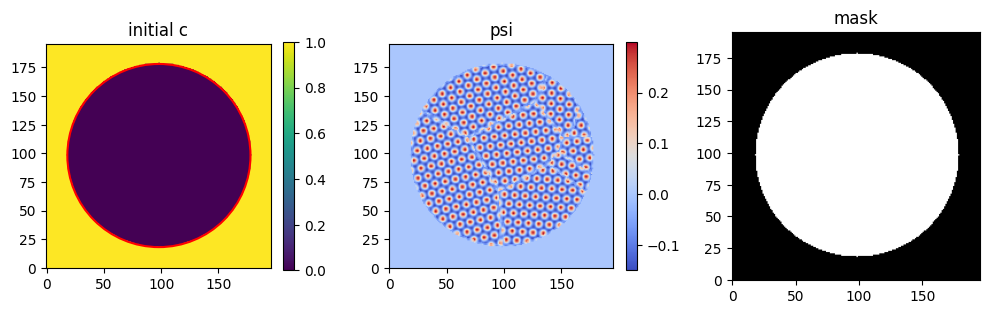

In [9]:
# --- Build params & fields ---

# Define the time step for the spectral PFC solver
pfc_spectral_dt = 1e-3 # Choose a suitable time step for the spectral solver

p = Params(nx=196, ny=196, r_electrode=80, r_outside=-0.2,
           r_inside=0.20, xi=0.1, gamma=1.2,
           kappa=4.0, RT=1.0, Om=2.0)

c, psi, r_field, mask = init_fields(p, seed=0)
fft_cache = build_fft_cache_from_params(p)

# Enforce intended initial condition: FePO4 inside (c≈0), Li reservoir outside (c=1)
c = np.where(mask, 0.0, 1.0).astype(float)

# Optional: seed psi with a simple polycrystal to avoid grid locking
psi0, labels, seeds, thetas = init_poly_voronoi_simple(
    p, mask, n_grains=8, amp=0.30, k=0.8, band_px=1, seed=4
)
# Short ψ warm-up at fixed c
#psi = pfc_relax_stable(psi0, c, r_field, p, mask=mask,
#                       n_steps=400, dt0=1e-5, dt_max=1e-4,
#                       psi_clip=1.8, enforce_amorphous=False, verbose_every=200)
psi = pfc_step_spectral(psi=psi0, c=c, r_field=r_field, p=p, cache=fft_cache,
                                  mask=mask, dt=pfc_spectral_dt, psi_clip=1.8)
_ = plot_fields(c, psi, mask, title_prefix='initial')
plt.show()

[step 0001] max|psi|=0.267, <c_in>=0.1715


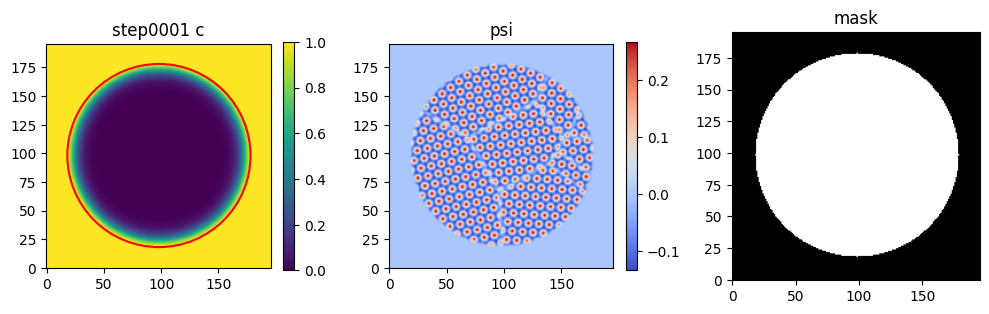

[step 0250] max|psi|=0.143, <c_in>=0.3828


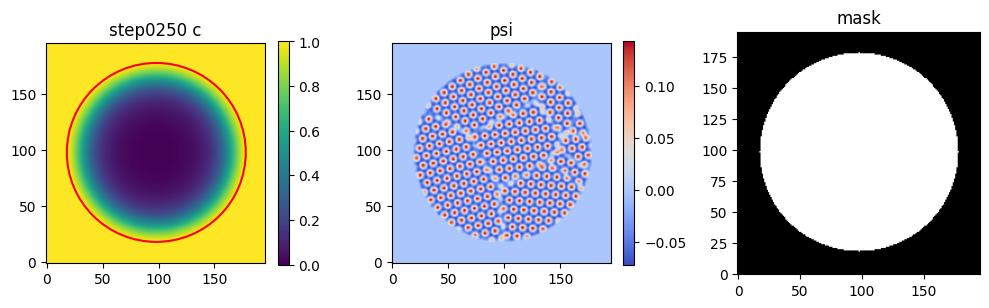

[step 0500] max|psi|=0.077, <c_in>=0.4961


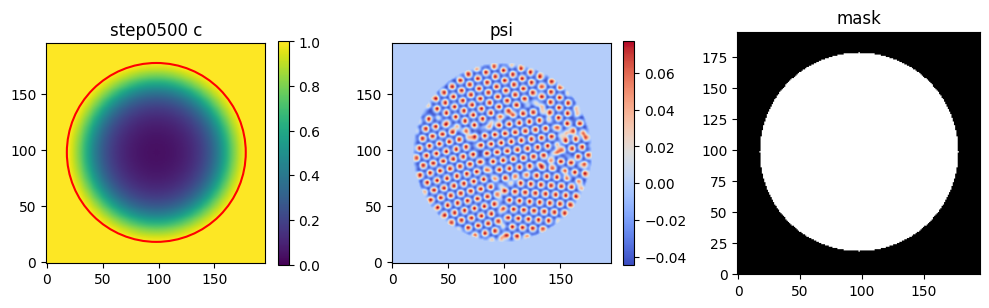

[step 0750] max|psi|=0.048, <c_in>=0.5788


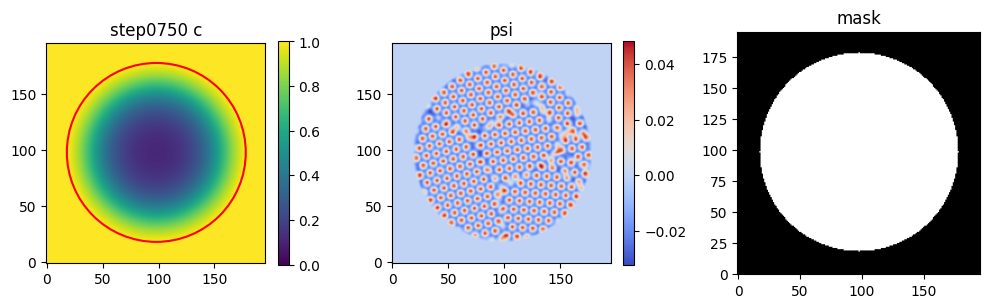

[step 1000] max|psi|=0.031, <c_in>=0.6444


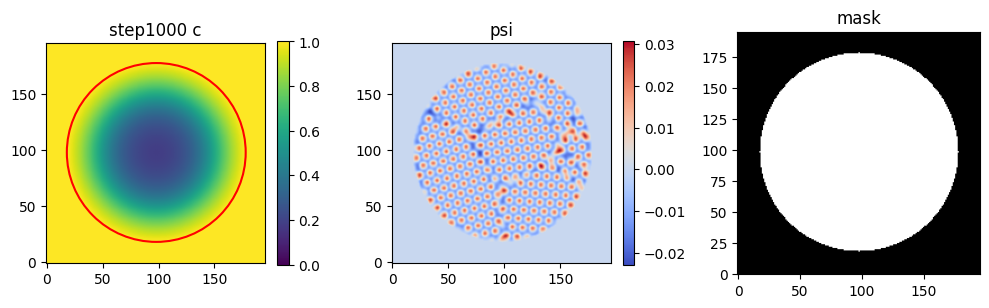

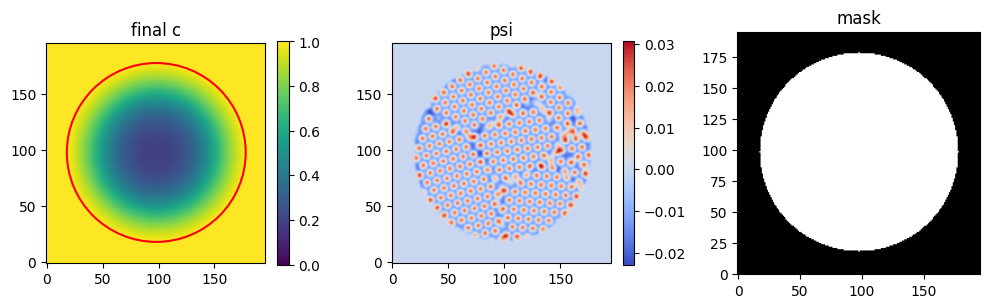

In [11]:
# --- Time integration (outer loop): ψ relax + spectral CH ---
n_outer   = 1000
pfc_steps = 800
pfc_spectral_dt = 1e-3 # Choose a suitable time step for the spectral solver
ch_dt     = 1e-3
ch_sub    = 5
mobility  = 100.0
save_every = 250
snapshots = []

for n in range(1, n_outer+1):
    # 1) relax psi at current c (fast inner relax)
#    psi = pfc_relax_stable(psi, c, r_field, p, mask=mask,
#                           n_steps=pfc_steps, dt0=1e-5, dt_max=5e-5,
#                           psi_clip=1.8, enforce_amorphous=False, verbose_every=0)
    psi = pfc_step_spectral(psi=psi, c=c, r_field=r_field, p=p, cache=fft_cache,
                                  mask=mask, dt=pfc_spectral_dt, psi_clip=1.8)
    # 2) CH update (spectral, semi-implicit)
    c = ch_step_spectral(c, psi, p, fft_cache, dt=ch_dt, n_sub=ch_sub,
                         mask=mask, mobility=mobility, kappa_iso=p.kappa,
                         mu_coupling=None, reservoir_value=1.0)

    # Diagnostics & snapshots
    if n % save_every == 0 or n in (1, n_outer):
        print(f"[step {n:04d}] max|psi|={np.abs(psi[mask]).max():.3f}, <c_in>={c[mask].mean():.4f}")
        snapshots.append((n, c.copy(), psi.copy()))
        _ = plot_fields(c, psi, mask, title_prefix='step'+str(n).zfill(4))
# --- Time integration (outer loop): ψ relax + spectral CH ---
        plt.show()
_ = plot_fields(c, psi, mask, title_prefix='final')
plt.show()

In [12]:
# Define extract_peak_coords function locally for use in this cell
def extract_peak_coords(psi, threshold=0.0, min_distance=2):
    """Find peak (lattice site) coordinates by detecting local maxima of ψ."""
    sm = gaussian_filter(psi, sigma=0.6)
    maxm = sm == maximum_filter(sm, size=(2*min_distance+1))
    coords = np.array(np.nonzero(maxm)).T
    vals = sm[maxm]
    keep = vals > threshold
    return coords[keep]

# Store extracted peak coordinates for each snapshot
snapshot_peak_coords = {}

# Iterate through the saved snapshots
for step, c_snap, psi_snap in snapshots:
    # Extract peak coordinates from the psi field within the mask
    # Adjust threshold and min_distance as needed based on the simulation results
    peak_coords = extract_peak_coords(psi_snap, threshold=0.01, min_distance=3)

    # Store the coordinates
    snapshot_peak_coords[step] = peak_coords
    print(f"Step {step}: Found {len(peak_coords)} lattice points.")

# You can now access the stored coordinates, e.g., for step 10:
# coords_step_10 = snapshot_peak_coords[10]

Step 1: Found 294 lattice points.
Step 250: Found 279 lattice points.
Step 500: Found 266 lattice points.
Step 750: Found 259 lattice points.
Step 1000: Found 254 lattice points.


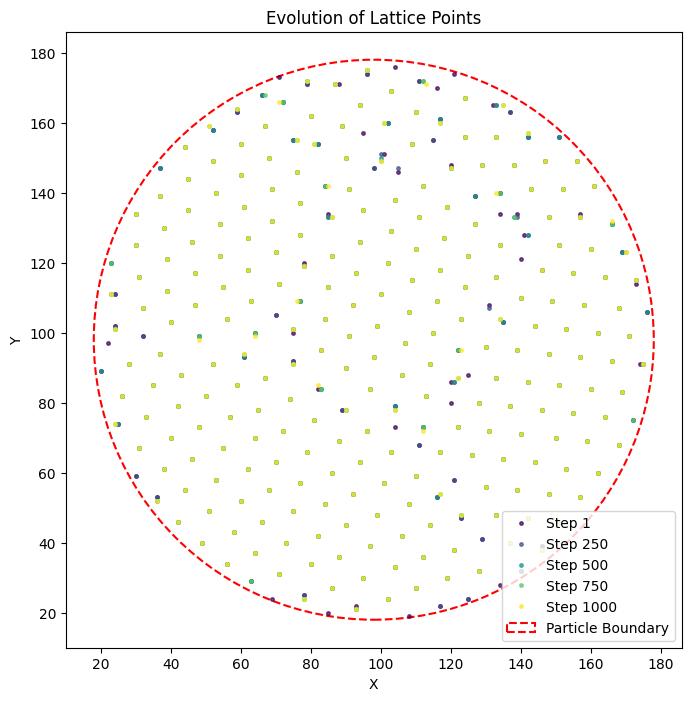

In [16]:
# Choose a few steps to visualize
# Updated steps based on the available snapshots (saved every 10 steps up to 100)
steps_to_visualize = [1, 250, 500, 750, 1000] # You can change these steps to any of [1, 10, 20, ..., 100]

plt.figure(figsize=(8, 8))

colors = plt.cm.viridis(np.linspace(0, 1, len(steps_to_visualize)))

for i, step in enumerate(steps_to_visualize):
    if step in snapshot_peak_coords:
        coords = snapshot_peak_coords[step]
        if len(coords) > 0:
            plt.plot(coords[:, 1], coords[:, 0], '.', color=colors[i], label=f'Step {step}', alpha=0.7, markersize=5)
        else:
            print(f"No lattice points found for step {step}")
    else:
        print(f"Snapshot for step {step} not found.")


# Add the particle boundary for reference
ny, nx = mask.shape
y_coords, x_coords = np.nonzero(mask)
if len(x_coords) > 0 and len(y_coords) > 0:
    center_x = np.mean(x_coords)
    center_y = np.mean(y_coords)
    area = np.sum(mask)
    radius = np.sqrt(area / np.pi)
    circle = plt.Circle((center_y, center_x), radius, color='red', fill=False, linewidth=1.5, linestyle='--', label='Particle Boundary')
    plt.gca().add_patch(circle)


plt.xlabel('X')
plt.ylabel('Y')
plt.title('Evolution of Lattice Points')
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

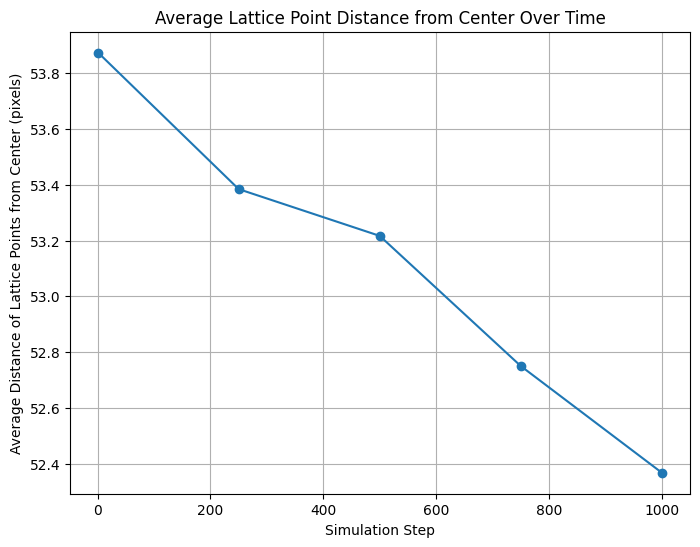

In [17]:
# Calculate the center of the particle from the mask
ny, nx = mask.shape
y_coords, x_coords = np.nonzero(mask)
center_x = np.mean(x_coords)
center_y = np.mean(y_coords)
center = np.array([center_y, center_x]) # Use (y, x) convention for consistency with coords

# Store average distances and steps
average_distances = []
steps = []

# Iterate through the saved snapshots
for step, peak_coords in snapshot_peak_coords.items():
    if len(peak_coords) > 0:
        # Calculate distances of all points from the center
        distances = np.linalg.norm(peak_coords - center, axis=1)
        # Calculate the average distance
        avg_dist = np.mean(distances)
        average_distances.append(avg_dist)
        steps.append(step)
    else:
        print(f"No lattice points found for step {step}, skipping.")

# Sort by step number
sorted_indices = np.argsort(steps)
sorted_steps = np.array(steps)[sorted_indices]
sorted_average_distances = np.array(average_distances)[sorted_indices]

# Plot the average distance vs. step number
plt.figure(figsize=(8, 6))
plt.plot(sorted_steps, sorted_average_distances, marker='o', linestyle='-')
plt.xlabel('Simulation Step')
plt.ylabel('Average Distance of Lattice Points from Center (pixels)')
plt.title('Average Lattice Point Distance from Center Over Time')
plt.grid(True)
plt.show()